# Systematics in caife

A variation of `examples/quickstart.ipynb` that showcases the treatment of systematic parameters in `caife` on synthetic toy data.

In [1]:
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt

import caife

## Toy data with systematic parameters

In contrast to the `examples/quickstart.ipynb` notebook, we will now generate a separate test set that spans only a part of the systematic parameter space. This setting resembles real analyses where the systematic parameters are not known with certainty and must be fitted.

In [2]:
from caife import examples

rng = np.random.default_rng(1491)

# create training data in the full space [-1, +1] of systematics S
X_trn, y_trn, w_trn, S_trn = examples.create_data(n_samples=100_000, rng=rng)

# create test data with some fixed systematics value 0.5
s_tst = 0.5
X_tst, y_tst, _, _ = examples.create_data(
    s_min=s_tst, s_max=s_tst, resample=True, n_samples=100_000, rng=rng)

# use the same binning as in examples/quickstart.ipynb
target_bins = np.concatenate(([-np.inf], np.linspace(-4, 5, 10), [np.inf]))
proxy_bins = np.concatenate(([-np.inf], np.linspace(-6, 8, 15), [np.inf]))

# retrieve the effective areas for the given target bins
a_eff = examples.create_effective_areas(target_bins)

We replace the simple linear count model from `examples/quickstart.ipynb` with a model that considers the systematic parameters.

In [3]:
model = caife.LinearSystematicsCountModel(
    target_bins, caife.UnivariateBinning(proxy_bins))
model.fit(X_trn, y_trn, sample_weight=w_trn, systematics=S_trn)

# log some information on the fit, including the wallclock time
print(model.opt_)

        message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
        success: True
         status: 0
            fun: 1.4862491130698607
              x: [ 2.729e-01  7.052e+00 ... -1.514e-01  6.522e+00]
            nit: 706
            jac: [ 2.015e-07 -1.985e-06 ... -2.272e-07  4.335e-07]
           nfev: 729
           njev: 729
       hess_inv: <352x352 LbfgsInvHessProduct with dtype=float64>
 wallclock_time: 48.26624941825867


## Matrix-valued response function

The systematics-aware model does not contain any fixed response matrix, but a **matrix-valued response function** with an output `model.A(s)` that changes with the systematic parameter vector `s`. This flexibility allows to fit the target spectrum `f` simultaneously with `s`, by inverting `g ≈ A(s) @ f + background`.

We can visualize `model.A(s)` to see how strongly `s` affects the detector response.

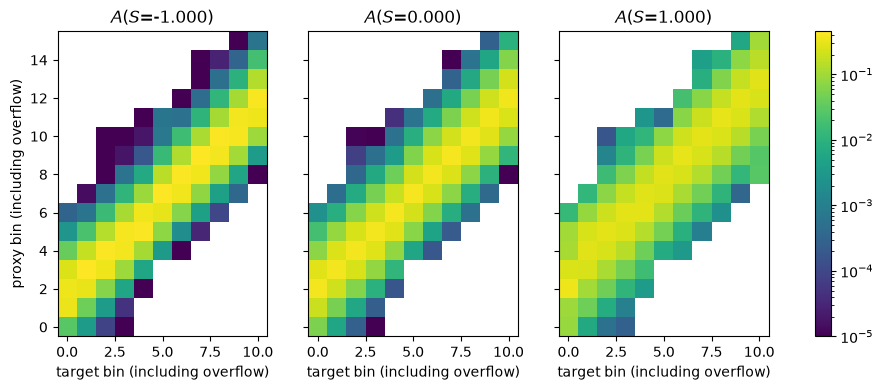

In [4]:
from matplotlib.colors import LogNorm

fig, axs = plt.subplots(1, 3, sharey=True, figsize=(10, 4))
norm = LogNorm(vmin=1e-5) # use the same norm across all plots

s_plt = np.stack((
    model.systematic_bounds[:,0], # lower bound
    model.systematic_bounds.mean(axis=1), # average systematic vector
    model.systematic_bounds[:,1], # upper bound
))
for ax, s in zip(axs, s_plt):
    imshow = ax.imshow(model.A(s), norm=norm, origin="lower")
    ax.set_title("$A$($S$=" + ", ".join([f"{s_i:.3f}" for s_i in s]) + ")")
    ax.set_xlabel("target bin (including overflow)")

axs[0].set_ylabel("proxy bin (including overflow)")
fig.tight_layout()
fig.colorbar(imshow, ax=axs)
plt.show()

A valuable cross-check for the quality of the matrix-valued response fit is whether an integration of its value across all training systematics yields the same matrix as a simple linear model would. In theory, the integration and the simple fixed matrix should be identical.

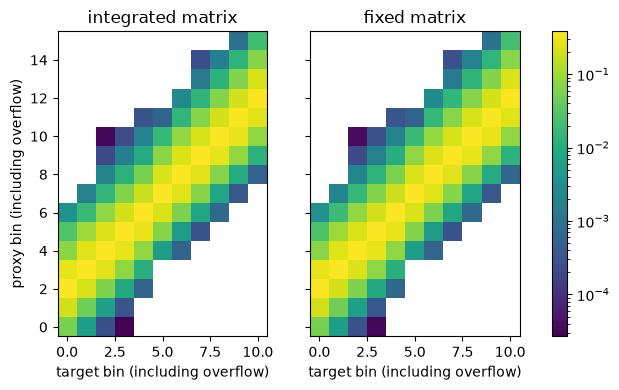

In [5]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(7, 4))
norm = LogNorm()

# integrate A(s) over s through random sampling (left plot)
A_avg = np.mean([ model.A(s) for s in S_trn[:1_000] ], axis=0)
axs[0].imshow(A_avg, norm=norm, origin="lower")

# plot A without systematics (right plot)
simple_model = caife.LinearCountModel(
    target_bins, caife.UnivariateBinning(proxy_bins))
simple_model.fit(X_trn, y_trn, sample_weight=w_trn);
imshow = axs[1].imshow(simple_model.A_, norm=norm, origin="lower")

for ax in axs:
    ax.set_xlabel("target bin (including overflow)")
axs[0].set_ylabel("proxy bin (including overflow)")
axs[0].set_title("integrated matrix")
axs[1].set_title("fixed matrix")
fig.tight_layout()
fig.colorbar(imshow, ax=axs)
plt.show()

## Setting up the likelihood with systematics

We now need to recover both `f` *and* `s` from the observed proxy spectrum `g_tst`. For this purpose, our `LinearSystematicsCountModel` creates two latent variables, instead of just one. Their structure also defines the structure of `params`, which becomes a pair `(f, s)`.

In [6]:
from jax import numpy as jnp # differentiable numpy wrapper

# inspect the structure of model parameters
print(model.create_latents(X_tst)) # -> a pair of latents for the spectrum and systematic parameters

# define the negative log-likelihood function from model parameters and optional hyper-parameters like tau
g_tst = model.proxy_view(X_tst)
def nll(params, tau): # params=(f, s), as we can see from model.create_latents(X_tst) above
    g_est = model(params) # apply the model to the parameters that are being fitted
    value = caife.poisson_nll(g_est, g_tst) # compute the negative log-likelihood loss
    value += caife.tikhonov_regularization( # add regularization to the spectrum, not to the systematics
        jnp.log(params[0][1:-1] / a_eff + 1e-10)) / tau
    return value

(LatentSpectrum(n_samples=100000, n_bins_target=11), LatentSystematics(bounds=array([[-0.9999909 ,  0.99999404]])))


The introduction of systematic parameters usually makes the unfolding problem non-convex. Since each run of our numeric solver can only find a local optimum of the likelihood, we need multiple optimization runs to find the best optimum among potentially multiple local optima. For this purpose, we need to increase the number of solutions that the solver is looking for.

In [7]:
solver = caife.ScipySolver(
    nll,
    model.create_latents(X_tst),
    min_valid_trials = 20, # find up to 20 valid solutions to pick the best from (default: 1)
    max_trials = 200, # allow more trials in total (default: 100)
    seed=1491,
)

## Jointly solving for the target spectrum and the systematic parameters

We invoke the solver and optimize the regularization strength `tau` as usual. The result that the solver now returns has the same structure as `params`.

In [8]:
import pandas as pd
from tqdm import tqdm

# obtain the truth to compare to (usually unknown)
f_tst = model.target_view(y_tst)

# consider many different tau values
results = []
tau_values = np.logspace(1, -5, 19)
for tau in tqdm(tau_values, ncols=80):

    # solve the unfolding task, just as above
    result, aux = solver.solve(args=(tau,), return_aux=True) # result is now a pair

    if result is not None: # only proceed if a valid solution was found
        f_est, s_est = result # unpack the result pair

        # estimate the uncertainties for both estimands f_est and s_est
        uncertainties = caife.uncertainty_from_aux(aux, rng=np.random.default_rng(1491))
        (f_lower, s_lower), (f_upper, s_upper) = uncertainties

        # assess the quality of the fit, according to several criteria
        gccs = caife.gcc_from_aux(aux, ignore_overflow_bins=(True, False)) # also returns a pair
        pcss = caife.pcs_from_aux(aux, ignore_overflow_bins=(True, False)) # also returns a pair
        cond = aux["cond"] # the condition number of the fit

        # also evaluate the true relative error, which is never available in practice
        rae = np.mean(np.abs(f_est[1:-1] - f_tst[1:-1]) / f_tst[1:-1])

        # store the results
        results.append({
            "tau": tau,
            "f_est": f_est,
            "f_lower": f_lower,
            "f_upper": f_upper,
            "s_est": s_est,
            "s_lower": s_lower,
            "s_upper": s_upper,
            "gcc": gccs[0], # only maintain the quality criteria of the spectrum
            "pcs": pcss[0],
            "cond": cond,
            "rae": rae,
            "aux": aux,
        })
results = pd.DataFrame(results)
print(f"Produced {len(results)}/{len(tau_values)} valid results") # invalid results are not stored

  0%|                                                    | 0/19 [00:00<?, ?it/s]

  5%|██▎                                         | 1/19 [00:08<02:24,  8.04s/it]

 11%|████▋                                       | 2/19 [00:14<01:58,  6.98s/it]

 16%|██████▉                                     | 3/19 [00:20<01:46,  6.64s/it]

 21%|█████████▎                                  | 4/19 [00:26<01:37,  6.49s/it]

...

 89%|██████████████████████████████████████▍    | 17/19 [01:43<00:11,  5.82s/it]

 95%|████████████████████████████████████████▋  | 18/19 [01:49<00:05,  5.81s/it]

100%|███████████████████████████████████████████| 19/19 [01:54<00:00,  5.82s/it]

100%|███████████████████████████████████████████| 19/19 [01:54<00:00,  6.05s/it]

Produced 19/19 valid results


We can now plot each of the the quality criteria against `tau` (colored points, left axes), together with the true relative error for reference (black points, right axes).

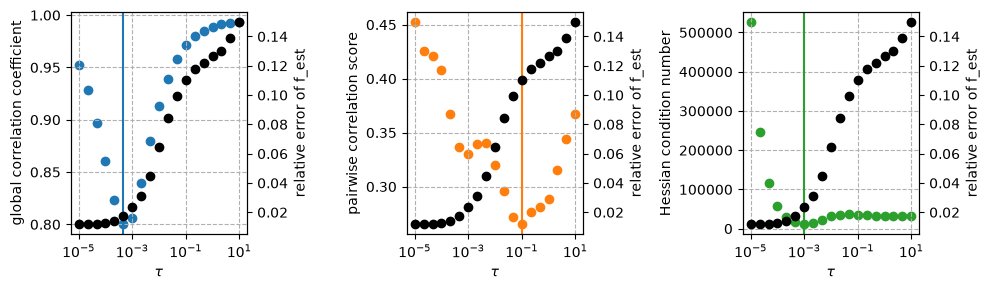

In [9]:
criteria = [ # pairs (name, column)
    ("global correlation coefficient", "gcc"),
    ("pairwise correlation score", "pcs"),
    ("Hessian condition number", "cond"),
]
fig, axs = plt.subplots(1, len(criteria), figsize=(10, 3)) # default figsize is (6.4, 4.8)

for i in range(len(criteria)):
    name_i, column_i = criteria[i]
    axs[i].scatter(results["tau"], results[column_i], color=f"C{i}")
    axs[i].axvline(results["tau"][np.argmin(results[column_i])], color=f"C{i}")
    axs[i].set_xlabel(r"$\tau$")
    axs[i].set_ylabel(name_i)
    axs[i].set_xscale("log")
    axs[i].grid(True, which="both", ls="--")
    twinx = axs[i].twinx()
    twinx.scatter(results["tau"], results["rae"], color="black")
    twinx.set_ylabel("relative error of f_est")

fig.tight_layout()
plt.show()

## Comparing the unfolded spectrum to the truth

Finally, we select one of the reconstructed spectrum according to the global correlation coefficient and compare it to the *true* target distribution of the test set, `f_tst`. This ground truth is only available because we generated this data ourselves; in a real experiment, `f_tst` is exactly what unfolding tries to recover from the observed proxy data alone.

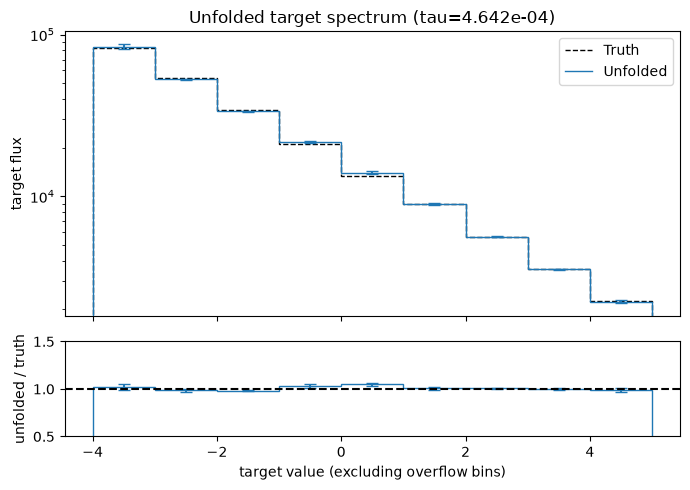

In [10]:
def plot_result(f_est, f_lower, f_upper, tau):
    target_bc = (target_bins[1:-2] + target_bins[2:-1]) / 2 # bin centers, excluding overflow bins
    
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    
    # upper panel: true and unfolded target fluxes
    ax1.stairs(f_tst[1:-1] / a_eff, edges=target_bins[1:-1], ls="dashed", color="black", label="Truth")
    ax1.stairs(f_est[1:-1] / a_eff, edges=target_bins[1:-1], color="C0", label="Unfolded")
    ax1.errorbar(
        target_bc, f_est[1:-1] / a_eff,
        yerr=np.stack((f_est[1:-1] - f_lower[1:-1], f_upper[1:-1] - f_est[1:-1])) / a_eff,
        color="C0", capsize=4, ls="",
    )
    ax1.set_yscale("log")
    ax1.set_ylabel("target flux")
    ax1.set_title(f"Unfolded target spectrum (tau={tau:.3e})")
    ax1.legend()
    
    # lower panel: unfolded spectrum divided by true spectrum (relative residuals)
    ax2.stairs(f_est[1:-1] / f_tst[1:-1], edges=target_bins[1:-1], color="C0")
    ax2.errorbar(
        target_bc, f_est[1:-1] / f_tst[1:-1],
        yerr=np.stack((f_est[1:-1] - f_lower[1:-1], f_upper[1:-1] - f_est[1:-1])) / f_tst[1:-1],
        color="C0", capsize=4, ls="",
    )
    ax2.axhline(1.0, color="black", ls="dashed")
    ax2.set_ylim((0.5, 1.5))
    ax2.set_xlabel("target value (excluding overflow bins)")
    ax2.set_ylabel("unfolded / truth")
    
    plt.tight_layout()
    plt.show()

# select the best result based on the global correlation coefficient
selected_result = results[results["gcc"]==results["gcc"].min()].iloc[0]
selected_f_est, selected_f_lower, selected_f_upper, selected_tau = selected_result[[
    "f_est", "f_lower", "f_upper", "tau"]]

# plot the result; it reconstructs the truth nicely!
plot_result(selected_f_est, selected_f_lower, selected_f_upper, selected_tau)

## Inspecting the fit of the systematics

We should also ask ourselves whether the systematics have been properly fitted. Since we generated the data ourselves, we know that their value is `s_tst`, and we can verify that our fit is somewhere close to this value.

Usually, we do not know the true range of the systematic parameter values. In this case, we can only check whether our fit is somewhat centered, assuming that the center value of the systematics describes the most likely parameter values. Keep in mind, though, that your systematics might be modeled under a uniform prior distribution, so that the unfolding procedure will assume all values to be equally likely despite your expectation of a somewhat centered fit.

In [11]:
s_est_lower, s_est_upper = selected_result[["s_lower", "s_upper"]]

print(f"The systematics fit ranges from {s_est_lower[0]:.3f} to {s_est_upper[0]:.3f} (+- 1 sigma)")
print(f"The true test systematics are {s_tst}")
print(f"The training systematics range from {model.systematic_bounds[0,0]:.3f} to {model.systematic_bounds[0,1]:.3f}")

The systematics fit ranges from 0.509 to 0.541 (+- 1 sigma)
The true test systematics are 0.5
The training systematics range from -1.000 to 1.000
